<a href="https://colab.research.google.com/github/adisberhe/pytorch-models-lab/blob/main/2_class_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sklearn
from sklearn.datasets import make_circles
import pandas as pd
import matplotlib.pyplot as plt
import torch

In [2]:
n_samples = 1000

X,y = make_circles(n_samples,
                   noise=0.3,
                   random_state=2,
                   factor= 0)
len(X),len(y) #y= 1 or 0 binary classification

(1000, 1000)

In [3]:
circles = pd.DataFrame({'feature1':X[:,0],
                        'feature2':X[:,1],
                        'target':y})
circles.head()

,feature1,feature2,target
0,0.429457,1.011365,0
1,0.177813,0.012938,1
2,0.104055,0.244327,1
3,-1.121552,-0.533581,0
4,0.055870,-0.264346,1


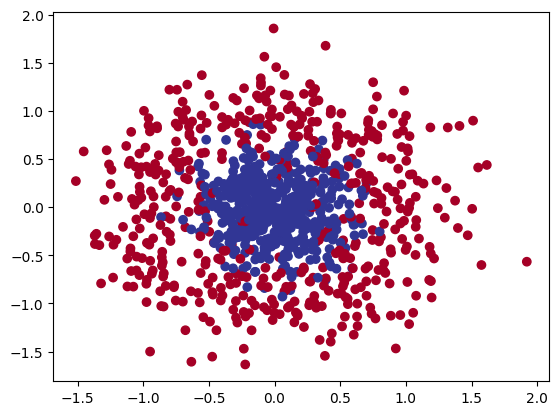

In [4]:
plt.scatter(x=X[:,0],
            y=X[:,1],
            c=y,
            cmap=plt.cm.RdYlBu
           );

In [5]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float) #------- run only one time, if not error saying it is not np array anymore
type(X),type(y)

(torch.Tensor, torch.Tensor)

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)
len(X_train),len(X_test),len(y_train),len(y_test)

(800, 200, 800, 200)

# Building the **Model**

In [7]:
from torch import nn
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [8]:
class CircleModelV0(nn.Module):
    def __init__(self):
      super().__init__()
      self.layer_1 = nn.Linear(in_features=2,out_features=128)
      self.layer_2 = nn.Linear(in_features=128,out_features=256)
      self.layer_3 = nn.Linear(in_features=256,out_features=1)
      self.relu = nn.ReLU()

    def forward(self,X):
      return self.layer_3(self.relu(self.layer_2(self.layer_1(X))))

#model_0 = nn.sequential(
    #nn.Linear(in_features=2,out_features=5),
    #nn.Linear(in_features=5,out_features=1)
#)
model_0 = CircleModelV0().to(device)



In [9]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(),
                        lr=0.1)

def accuracy_fn(y_true,y_pred):
  correct = torch.eq(y_true,y_pred).sum().item()
  acc = (correct/len(y_pred))*100
  return acc
#

In [10]:
torch.cuda.manual_seed(42)
epochs = 1000

X_train, X_test, y_train, y_test = X_train.to(device), X_test.to(device), y_train.to(device), y_test.to(device)

for epoch in range(epochs):
  model_0.train()
  y_logits = model_0(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits.to(device)))

  loss = loss_fn(y_logits,y_train)
  acc = accuracy_fn(y_train,y_pred)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_0.eval()
  with torch.inference_mode():
    test_logits = model_0(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits,y_test)
    test_acc = accuracy_fn(y_test,test_pred)
  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69246 | Acc: 50.00% | Test Loss: 0.68537 | Test Acc: 50.00%
Epoch: 100 | Loss: 0.30578 | Acc: 89.88% | Test Loss: 0.32743 | Test Acc: 90.00%
Epoch: 200 | Loss: 0.23161 | Acc: 89.75% | Test Loss: 0.25201 | Test Acc: 90.50%
Epoch: 300 | Loss: 0.21838 | Acc: 89.88% | Test Loss: 0.23875 | Test Acc: 90.50%
Epoch: 400 | Loss: 0.21488 | Acc: 89.88% | Test Loss: 0.23548 | Test Acc: 90.50%
Epoch: 500 | Loss: 0.21357 | Acc: 90.12% | Test Loss: 0.23439 | Test Acc: 91.00%
Epoch: 600 | Loss: 0.21286 | Acc: 90.00% | Test Loss: 0.23381 | Test Acc: 91.00%
Epoch: 700 | Loss: 0.21253 | Acc: 90.00% | Test Loss: 0.23386 | Test Acc: 91.00%
Epoch: 800 | Loss: 0.21237 | Acc: 89.88% | Test Loss: 0.23409 | Test Acc: 91.00%
Epoch: 900 | Loss: 0.21212 | Acc: 90.00% | Test Loss: 0.23418 | Test Acc: 91.00%


In [11]:
import requests
from pathlib import Path

if Path('helper_functions.py').is_file():
  print('Helper functions already downloaded')
else:
  print('Downloading helper functions...')
  request = requests.get('https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py')
  with open('helper_functions.py','wb') as f:
    f.write(request.content)

from helper_functions import plot_predictions,plot_decision_boundary

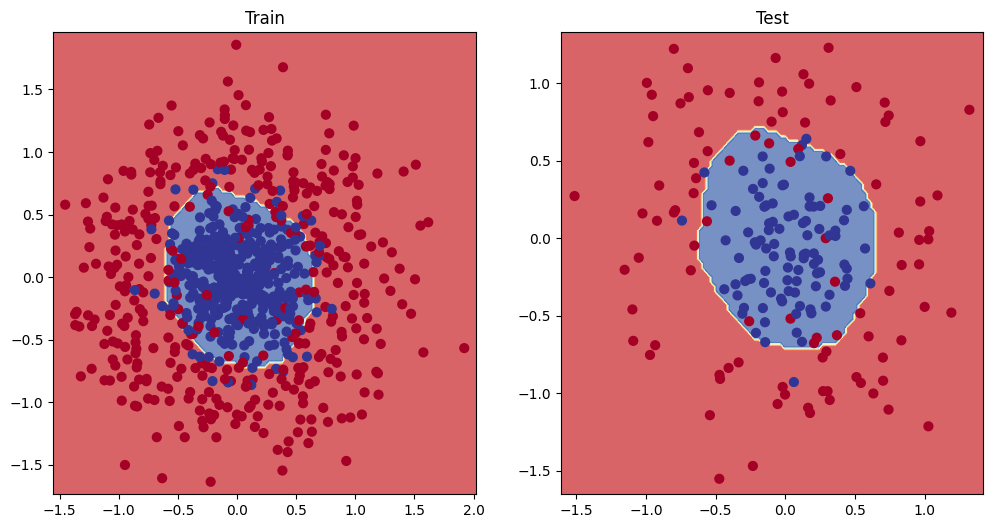

In [12]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title('Train')
plot_decision_boundary(model_0,X_train,y_train)
plt.subplot(1,2,2)
plt.title('Test')
plot_decision_boundary(model_0,X_test,y_test)

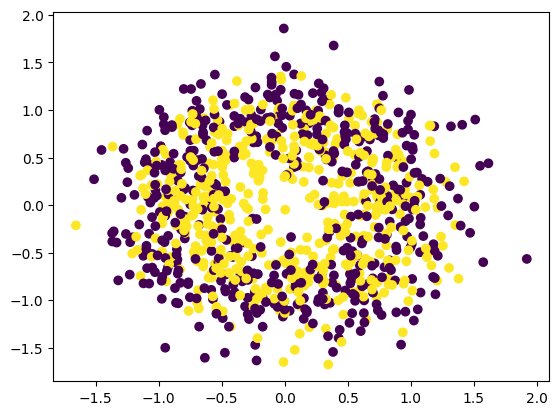

In [13]:
samples = 1000
X,y = make_circles(n_samples,
                   noise=0.3,
                   random_state=2)
len(X),len(y) #y= 1 or 0 binary classification
plt.scatter(X[:,0],X[:,1],c=y)

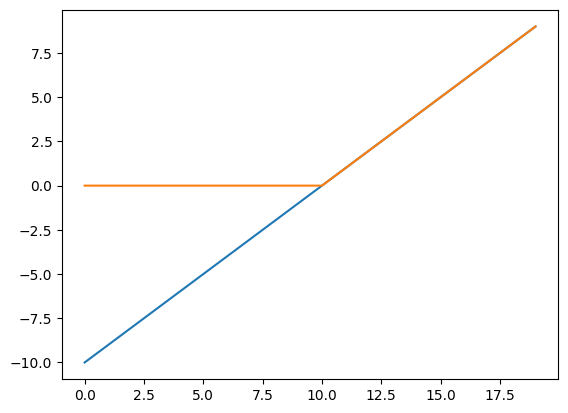

In [14]:
data = torch.arange(-10,10,1)
plt.plot(data)
plt.plot(torch.relu(data))